In [1]:
# AI in HealthCare
# Lab Experiment 1

In [2]:


!pip -q install pandas numpy matplotlib scikit-learn wfdb pillow requests openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 1.3 MB/s eta 0:00:00


In [3]:
# ============================================================
# CELL 2: IMPORT LIBRARIES
# ============================================================

import os
import re
import json
import requests
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from io import BytesIO

import wfdb

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# Part A {Tabular Data}

# ============================================================
# CELL 3: DOWNLOAD CLEVELAND HEART DISEASE DATASET
# ============================================================

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

heart_df = pd.read_csv(
    url,
    names=columns,
    na_values="?"
)

print("Dataset downloaded successfully!")
print("Shape:", heart_df.shape)

heart_df.head()

Dataset downloaded successfully!
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [5]:
# ============================================================
# CELL 4: DATASET INSPECTION
# ============================================================

print("Number of rows:", heart_df.shape[0])
print("Number of columns:", heart_df.shape[1])

print("\nColumn Names:")
print(list(heart_df.columns))

print("\nData Types:")
print(heart_df.dtypes)

print("\nMissing Values:")
print(heart_df.isnull().sum())

print("\nStatistical Summary:")
display(heart_df.describe())

Number of rows: 303
Number of columns: 14

Column Names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data Types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [6]:
# ============================================================
# CELL 5: HANDLE MISSING VALUES
# ============================================================

print("Missing values before preprocessing:")
print(heart_df.isnull().sum())

# Convert all columns to numeric
heart_df = heart_df.apply(pd.to_numeric, errors="coerce")

# Fill missing values using median
for column in heart_df.columns:
    if heart_df[column].isnull().sum() > 0:
        heart_df[column] = heart_df[column].fillna(
            heart_df[column].median()
        )

print("\nMissing values after preprocessing:")
print(heart_df.isnull().sum())

Missing values before preprocessing:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Missing values after preprocessing:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [7]:
# ============================================================
# CELL 6: TARGET CONVERSION
# ============================================================

heart_df["target"] = (heart_df["target"] > 0).astype(int)

print("Target distribution:")
print(heart_df["target"].value_counts())

print("\nTarget meaning:")
print("0 = No heart disease")
print("1 = Heart disease present")

Target distribution:
target
0    164
1    139
Name: count, dtype: int64

Target meaning:
0 = No heart disease
1 = Heart disease present


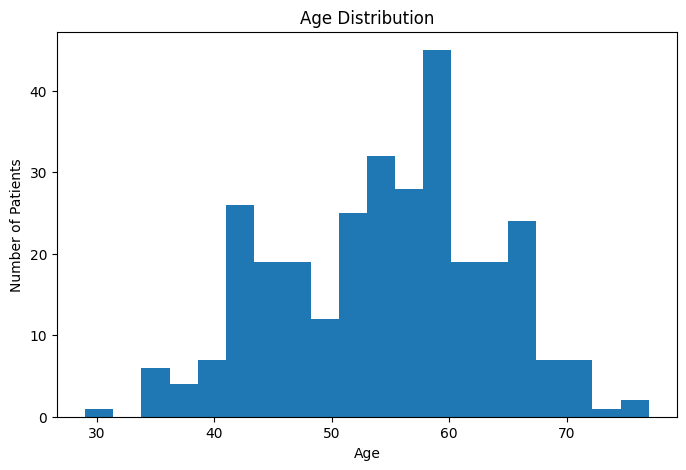

In [8]:
# ============================================================
# CELL 7: BASIC EDA
# ============================================================

# Age distribution
plt.figure(figsize=(8, 5))

plt.hist(heart_df["age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

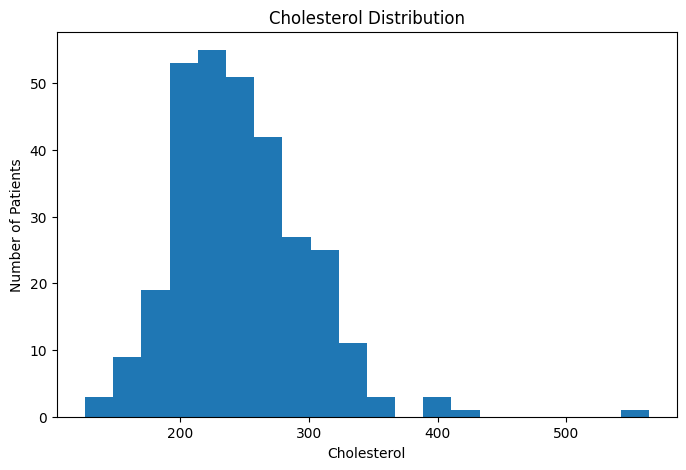

In [9]:
# ============================================================
# CELL 8: CHOLESTEROL DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(heart_df["chol"], bins=20)

plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Number of Patients")

plt.show()

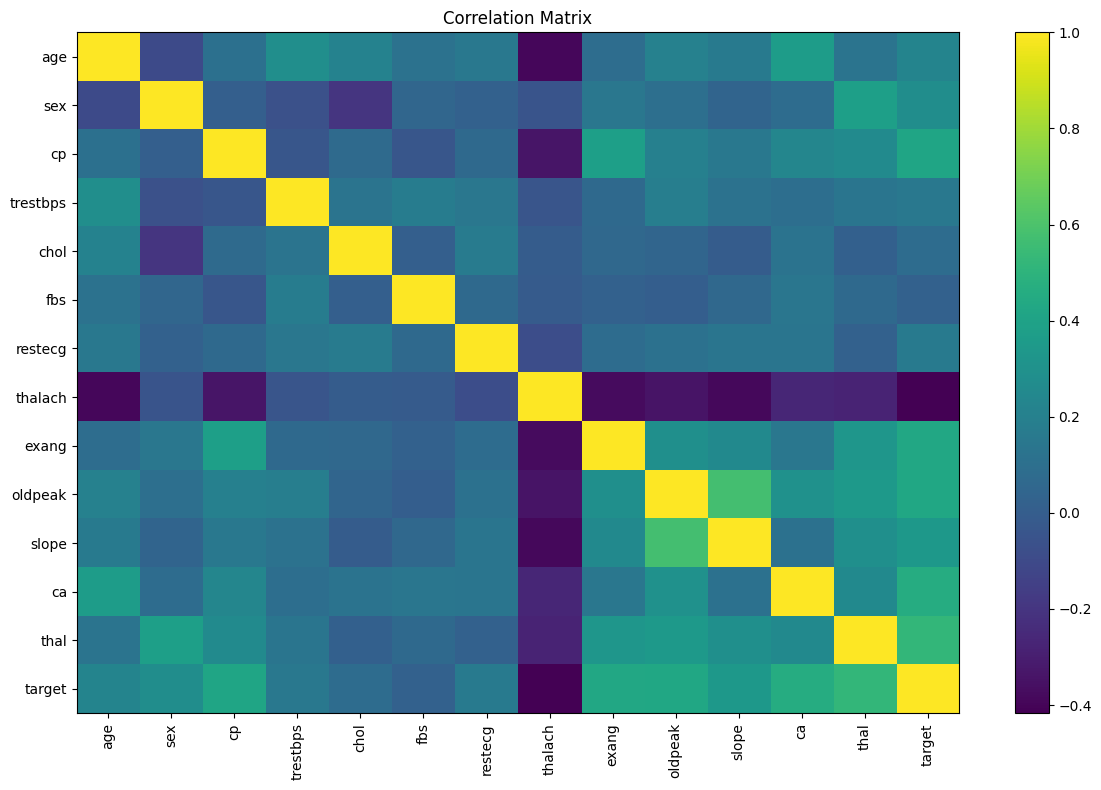

In [10]:
# ============================================================
# CELL 9: CORRELATION MATRIX
# ============================================================

correlation = heart_df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

plt.imshow(correlation, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# CELL 10: PREPARE DATA FOR MACHINE LEARNING
# ============================================================

X = heart_df.drop("target", axis=1)
y = heart_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 242
Testing samples: 61


In [12]:
# ============================================================
# CELL 11: LOGISTIC REGRESSION MODEL
# ============================================================

model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(max_iter=1000)
    )
])

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [13]:
# ============================================================
# CELL 12: MODEL EVALUATION
# ============================================================

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Model Performance")
print("---------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Performance
---------------------------
Accuracy : 0.8689
ROC-AUC  : 0.9513

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



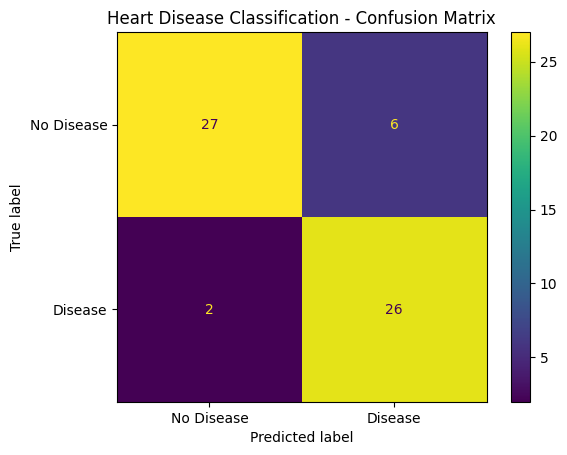

In [14]:
# ============================================================
# CELL 13: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)

disp.plot()

plt.title("Heart Disease Classification - Confusion Matrix")

plt.show()

In [15]:
# Part B [Textual Data]

# ============================================================
# CELL 14: TEXTUAL DATA - SYNTHETIC CLINICAL NOTE
# ============================================================

clinical_note = """
Patient reports chest pain during physical activity.
The patient also reports shortness of breath and occasional fatigue.
Blood pressure is elevated.
The patient has a history of high cholesterol.
ECG examination is recommended for further evaluation.
"""

# Save as TXT file
with open("patient_note.txt", "w") as file:
    file.write(clinical_note)

print("Clinical note created successfully!")

Clinical note created successfully!


In [16]:
# ============================================================
# CELL 15: READ TEXT FILE
# ============================================================

with open("patient_note.txt", "r") as file:
    text = file.read()

print("Clinical Note:")
print("----------------")
print(text)

Clinical Note:
----------------

Patient reports chest pain during physical activity.
The patient also reports shortness of breath and occasional fatigue.
Blood pressure is elevated.
The patient has a history of high cholesterol.
ECG examination is recommended for further evaluation.



In [17]:
# ============================================================
# CELL 16: TEXT CLEANING AND TOKENIZATION
# ============================================================

# Convert to lowercase
clean_text = text.lower()

# Extract words
tokens = re.findall(r"\b[a-z]+\b", clean_text)

print("Tokens:")
print(tokens)

print("\nTotal number of tokens:", len(tokens))

Tokens:
['patient', 'reports', 'chest', 'pain', 'during', 'physical', 'activity', 'the', 'patient', 'also', 'reports', 'shortness', 'of', 'breath', 'and', 'occasional', 'fatigue', 'blood', 'pressure', 'is', 'elevated', 'the', 'patient', 'has', 'a', 'history', 'of', 'high', 'cholesterol', 'ecg', 'examination', 'is', 'recommended', 'for', 'further', 'evaluation']

Total number of tokens: 36


In [18]:
# ============================================================
# CELL 17: SIMPLE STOPWORD REMOVAL
# ============================================================

stopwords = {
    "the", "is", "a", "an", "and", "of",
    "to", "for", "with", "during", "also",
    "has", "on", "in", "patient", "reports"
}

filtered_tokens = [
    word for word in tokens
    if word not in stopwords
]

print("Tokens after stopword removal:")
print(filtered_tokens)

Tokens after stopword removal:
['chest', 'pain', 'physical', 'activity', 'shortness', 'breath', 'occasional', 'fatigue', 'blood', 'pressure', 'elevated', 'history', 'high', 'cholesterol', 'ecg', 'examination', 'recommended', 'further', 'evaluation']


In [19]:
# ============================================================
# CELL 18: WORD FREQUENCY
# ============================================================

word_frequency = Counter(filtered_tokens)

print("Word Frequency:")
for word, count in word_frequency.most_common():
    print(f"{word}: {count}")

Word Frequency:
chest: 1
pain: 1
physical: 1
activity: 1
shortness: 1
breath: 1
occasional: 1
fatigue: 1
blood: 1
pressure: 1
elevated: 1
history: 1
high: 1
cholesterol: 1
ecg: 1
examination: 1
recommended: 1
further: 1
evaluation: 1


In [20]:
# ============================================================
# CELL 19: EXTRACT KEY MEDICAL TERMS
# ============================================================

medical_keywords = [
    "chest",
    "pain",
    "shortness",
    "breath",
    "fatigue",
    "blood",
    "pressure",
    "cholesterol",
    "ecg"
]

found_terms = [
    word for word in medical_keywords
    if word in filtered_tokens
]

print("Important medical terms detected:")
print(found_terms)

Important medical terms detected:
['chest', 'pain', 'shortness', 'breath', 'fatigue', 'blood', 'pressure', 'cholesterol', 'ecg']


In [21]:
# Part C [Image Data]

# ============================================================
# CELL 20: CREATE SYNTHETIC MEDICAL IMAGE
# ============================================================

image_array = np.zeros((256, 256), dtype=np.uint8)

# Create circular structures resembling a simple anatomical illustration
y, x = np.ogrid[:256, :256]

center_x = 128
center_y = 128

distance = np.sqrt(
    (x - center_x) ** 2 +
    (y - center_y) ** 2
)

image_array[distance < 80] = 100
image_array[distance < 60] = 150
image_array[distance < 40] = 220

synthetic_image = Image.fromarray(image_array)

synthetic_image.save("synthetic_medical_image.png")

print("Synthetic medical image saved!")

Synthetic medical image saved!


Image format: PNG
Image mode: L
Image size: (256, 256)


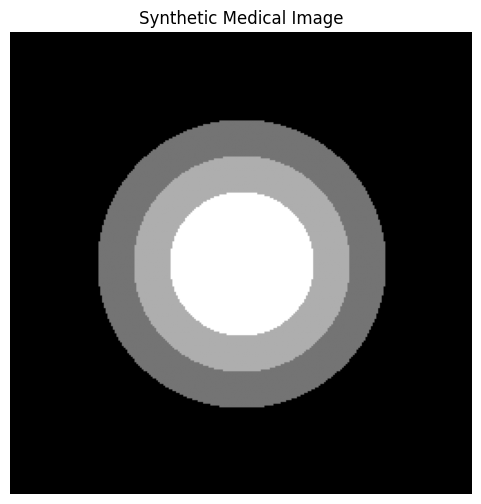

In [22]:
# ============================================================
# CELL 21: READ AND DISPLAY IMAGE
# ============================================================

image = Image.open("synthetic_medical_image.png")

print("Image format:", image.format)
print("Image mode:", image.mode)
print("Image size:", image.size)

plt.figure(figsize=(6, 6))

plt.imshow(image, cmap="gray")

plt.title("Synthetic Medical Image")
plt.axis("off")

plt.show()

Original image size: (256, 256)
Resized image size: (128, 128)
Pixel value range after normalization: 0.0 to 0.8784313725490196


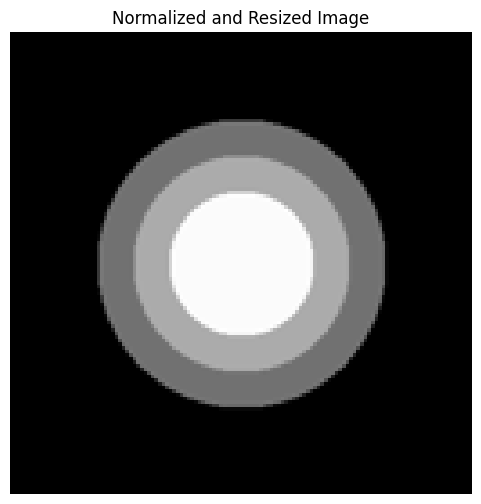

In [23]:
# ============================================================
# CELL 22: IMAGE PREPROCESSING
# ============================================================

# Resize
resized_image = image.resize((128, 128))

# Convert to NumPy array
image_array = np.array(resized_image)

# Normalize pixel values from 0-255 to 0-1
normalized_image = image_array / 255.0

print("Original image size:", image.size)
print("Resized image size:", resized_image.size)

print(
    "Pixel value range after normalization:",
    normalized_image.min(),
    "to",
    normalized_image.max()
)

plt.figure(figsize=(6, 6))

plt.imshow(normalized_image, cmap="gray")

plt.title("Normalized and Resized Image")
plt.axis("off")

plt.show()

In [25]:
# Part D [Signal Data/ ECG]

# ============================================================
# CELL 23: DOWNLOAD MIT-BIH ECG RECORD 100
# ============================================================

import os
import time
import requests
import wfdb

record_name = "100"

# Local directory for ECG files
os.makedirs("mitdb", exist_ok=True)

# Official PhysioNet files for record 100
base_url = "https://physionet.org/files/mitdb/1.0.0"

files = [
    "100.hea",
    "100.dat",
    "100.atr"
]

# Download each file
for filename in files:

    file_path = os.path.join("mitdb", filename)
    file_url = f"{base_url}/{filename}"

    # Skip if already downloaded
    if os.path.exists(file_path):
        print(f"Already exists: {filename}")
        continue

    print(f"Downloading {filename}...")

    for attempt in range(3):
        try:
            response = requests.get(
                file_url,
                timeout=60
            )

            response.raise_for_status()

            with open(file_path, "wb") as f:
                f.write(response.content)

            print(f"Downloaded successfully: {filename}")
            break

        except Exception as e:

            print(
                f"Attempt {attempt + 1} failed for {filename}: {e}"
            )

            if attempt < 2:
                print("Retrying...")
                time.sleep(3)
            else:
                raise RuntimeError(
                    f"Could not download {filename}. "
                    "PhysioNet may be temporarily unavailable."
                )

# ------------------------------------------------------------
# READ THE ECG RECORD LOCALLY
# ------------------------------------------------------------

record = wfdb.rdrecord(
    "mitdb/100"
)

annotation = wfdb.rdann(
    "mitdb/100",
    "atr"
)

print("\nECG record loaded successfully!")

print("\nSampling Frequency:")
print(record.fs, "Hz")

print("\nNumber of samples:")
print(record.sig_len)

print("\nNumber of channels:")
print(record.n_sig)

print("\nSignal names:")
print(record.sig_name)

print("\nNumber of annotations:")
print(len(annotation.sample))

Downloaded successfully: 100.hea
Downloaded successfully: 100.dat
Downloaded successfully: 100.atr

ECG record loaded successfully!

Sampling Frequency:
360 Hz

Number of samples:
650000

Number of channels:
2

Signal names:
['MLII', 'V5']

Number of annotations:
2274


In [26]:
# ============================================================
# CELL 24: INSPECT ECG DATA
# ============================================================

ecg_signal = record.p_signal[:, 0]

print("ECG signal shape:", ecg_signal.shape)

print("\nFirst 20 ECG samples:")
print(ecg_signal[:20])

print("\nMinimum:", np.min(ecg_signal))
print("Maximum:", np.max(ecg_signal))
print("Mean:", np.mean(ecg_signal))
print("Standard deviation:", np.std(ecg_signal))

ECG signal shape: (650000,)

First 20 ECG samples:
[-0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.12  -0.135
 -0.145 -0.15  -0.16  -0.155 -0.16  -0.175 -0.18  -0.185 -0.17  -0.155]

Minimum: -2.715
Maximum: 1.435
Mean: -0.3062989769230769
Standard deviation: 0.19319954213721688


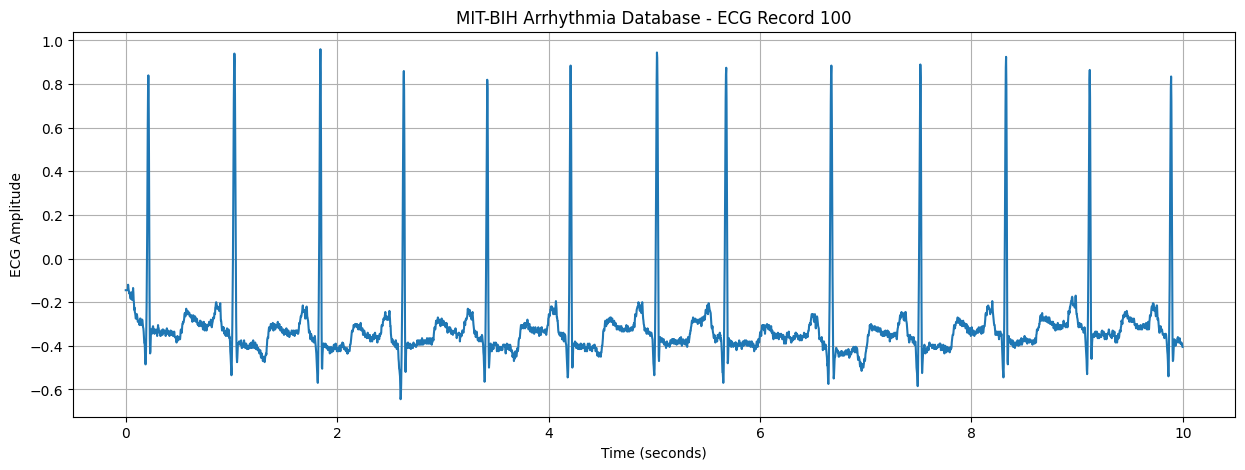

In [27]:
# ============================================================
# CELL 25: PLOT ECG WAVEFORM
# ============================================================

sampling_frequency = record.fs

# Plot first 10 seconds
seconds = 10
samples = int(seconds * sampling_frequency)

time = np.arange(samples) / sampling_frequency

plt.figure(figsize=(15, 5))

plt.plot(
    time,
    ecg_signal[:samples]
)

plt.title("MIT-BIH Arrhythmia Database - ECG Record 100")
plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")
plt.grid(True)

plt.show()

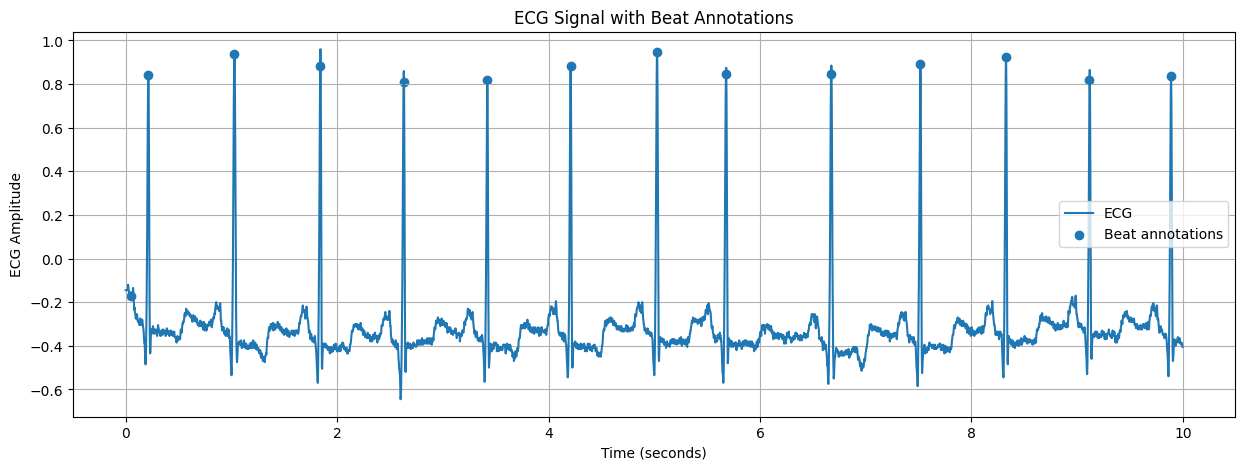

Annotations in first 10 seconds:
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N']


In [28]:
# ============================================================
# CELL 26: ECG WITH ANNOTATIONS
# ============================================================

seconds = 10
samples = int(seconds * sampling_frequency)

time = np.arange(samples) / sampling_frequency

# Annotation samples within first 10 seconds
annotation_samples = annotation.sample[
    annotation.sample < samples
]

annotation_symbols = [
    annotation.symbol[i]
    for i, sample in enumerate(annotation.sample)
    if sample < samples
]

plt.figure(figsize=(15, 5))

plt.plot(
    time,
    ecg_signal[:samples],
    label="ECG"
)

plt.scatter(
    annotation_samples / sampling_frequency,
    ecg_signal[annotation_samples],
    marker="o",
    label="Beat annotations"
)

plt.title("ECG Signal with Beat Annotations")
plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")

plt.legend()
plt.grid(True)

plt.show()

print("Annotations in first 10 seconds:")
print(annotation_symbols)

In [29]:
# ============================================================
# CELL 27: ECG BEAT INTERVAL ANALYSIS
# ============================================================

# Convert annotation locations to seconds
beat_times = annotation.sample / sampling_frequency

# Calculate intervals between consecutive annotations
rr_intervals = np.diff(beat_times)

# Keep reasonable intervals for basic analysis
rr_intervals = rr_intervals[
    (rr_intervals > 0.3) &
    (rr_intervals < 2.0)
]

print("Number of valid beat intervals:", len(rr_intervals))

print("\nMean RR interval:",
      np.mean(rr_intervals), "seconds")

print("Median RR interval:",
      np.median(rr_intervals), "seconds")

print("Standard deviation of RR intervals:",
      np.std(rr_intervals), "seconds")

Number of valid beat intervals: 2272

Mean RR interval: 0.794593603286385 seconds
Median RR interval: 0.7972222222222172 seconds
Standard deviation of RR intervals: 0.04883539560305922 seconds


In [30]:
# ============================================================
# CELL 28: ESTIMATE HEART RATE
# ============================================================

mean_rr = np.mean(rr_intervals)

estimated_heart_rate = 60 / mean_rr

print(
    f"Estimated average heart rate: "
    f"{estimated_heart_rate:.2f} BPM"
)

Estimated average heart rate: 75.51 BPM


In [31]:
# Part E [medical Data integration]

# ============================================================
# CELL 29: MULTIMODAL MEDICAL DATA
# ============================================================

patient_id = "P001"

# Select one patient from tabular dataset
patient_data = heart_df.iloc[0]

# ECG-derived features
ecg_features = {
    "mean_rr_interval": float(np.mean(rr_intervals)),
    "rr_std": float(np.std(rr_intervals)),
    "estimated_heart_rate": float(estimated_heart_rate)
}

# Image-derived features
image_features = {
    "image_width": image.size[0],
    "image_height": image.size[1],
    "mean_pixel_value": float(normalized_image.mean()),
    "max_pixel_value": float(normalized_image.max())
}

# Text-derived features
text_features = {
    "number_of_tokens": len(tokens),
    "number_of_medical_terms": len(found_terms),
    "medical_terms": found_terms
}

# Create multimodal record
multimodal_patient = {
    "patient_id": patient_id,

    "tabular_data": {
        "age": float(patient_data["age"]),
        "sex": float(patient_data["sex"]),
        "cholesterol": float(patient_data["chol"]),
        "resting_blood_pressure": float(patient_data["trestbps"]),
        "target": int(patient_data["target"])
    },

    "text_data": text_features,

    "image_data": image_features,

    "ecg_data": ecg_features
}

print("MULTIMODAL PATIENT RECORD")
print("=========================")

print(
    json.dumps(
        multimodal_patient,
        indent=4
    )
)

MULTIMODAL PATIENT RECORD
{
    "patient_id": "P001",
    "tabular_data": {
        "age": 63.0,
        "sex": 1.0,
        "cholesterol": 233.0,
        "resting_blood_pressure": 145.0,
        "target": 0
    },
    "text_data": {
        "number_of_tokens": 36,
        "number_of_medical_terms": 9,
        "medical_terms": [
            "chest",
            "pain",
            "shortness",
            "breath",
            "fatigue",
            "blood",
            "pressure",
            "cholesterol",
            "ecg"
        ]
    },
    "image_data": {
        "image_width": 256,
        "image_height": 256,
        "mean_pixel_value": 0.1750102922028186,
        "max_pixel_value": 0.8784313725490196
    },
    "ecg_data": {
        "mean_rr_interval": 0.794593603286385,
        "rr_std": 0.04883539560305922,
        "estimated_heart_rate": 75.51029828561933
    }
}


In [32]:
# ============================================================
# CELL 30: UNIFIED MULTIMODAL DATASET
# ============================================================

unified_record = pd.DataFrame([{
    "patient_id": patient_id,

    # Tabular features
    "age": patient_data["age"],
    "sex": patient_data["sex"],
    "cholesterol": patient_data["chol"],
    "resting_bp": patient_data["trestbps"],

    # Text features
    "text_token_count": len(tokens),
    "medical_keyword_count": len(found_terms),

    # Image features
    "image_mean": normalized_image.mean(),
    "image_max": normalized_image.max(),

    # ECG features
    "mean_rr": np.mean(rr_intervals),
    "rr_std": np.std(rr_intervals),
    "estimated_heart_rate": estimated_heart_rate,

    # Target
    "heart_disease": patient_data["target"]
}])

display(unified_record)

,patient_id,age,sex,cholesterol,resting_bp,text_token_count,medical_keyword_count,image_mean,image_max,mean_rr,rr_std,estimated_heart_rate,heart_disease
0,P001,63.0,1.0,233.0,145.0,36,9,0.17501,0.878431,0.794594,0.048835,75.510298,0.0


In [33]:
# ============================================================
# CELL 31: EXPORT DATA
# ============================================================

unified_record.to_csv(
    "multimodal_patient_dataset.csv",
    index=False
)

with open(
    "clinical_note_processed.txt",
    "w"
) as file:
    file.write(
        "Extracted Medical Terms:\n"
        + ", ".join(found_terms)
        + "\n\n"
        + "Original Clinical Note:\n"
        + text
    )

print("Files exported successfully!")
print("1. multimodal_patient_dataset.csv")
print("2. clinical_note_processed.txt")

Files exported successfully!
1. multimodal_patient_dataset.csv
2. clinical_note_processed.txt


In [34]:
# ============================================================
# CELL 32: FINAL SUMMARY
# ============================================================

print("=" * 60)
print("       MULTIMODAL HEALTHCARE DATA INGESTION")
print("=" * 60)

print("\n1. TABULAR DATA")
print("----------------")
print("Dataset: UCI Cleveland Heart Disease")
print("Records:", heart_df.shape[0])
print("Features:", heart_df.shape[1] - 1)
print("Target: Heart disease")

print("\n2. TEXTUAL DATA")
print("----------------")
print("File: patient_note.txt")
print("Number of tokens:", len(tokens))
print("Medical keywords found:", found_terms)

print("\n3. IMAGE DATA")
print("----------------")
print("Format:", image.format)
print("Original size:", image.size)
print("Processed size:", resized_image.size)

print("\n4. SIGNAL DATA")
print("----------------")
print("Dataset: MIT-BIH Arrhythmia Database")
print("Record:", record_name)
print("Sampling frequency:", record.fs, "Hz")
print("ECG channels:", record.n_sig)
print("Estimated heart rate:",
      round(estimated_heart_rate, 2), "BPM")

print("\n5. MEDICAL DATA")
print("----------------")
print("Patient ID:", patient_id)
print("Modalities integrated:")
print("- Tabular")
print("- Text")
print("- Image")
print("- ECG Signal")

print("\n" + "=" * 60)
print("              EXPERIMENT COMPLETED")
print("=" * 60)

       MULTIMODAL HEALTHCARE DATA INGESTION

1. TABULAR DATA
----------------
Dataset: UCI Cleveland Heart Disease
Records: 303
Features: 13
Target: Heart disease

2. TEXTUAL DATA
----------------
File: patient_note.txt
Number of tokens: 36
Medical keywords found: ['chest', 'pain', 'shortness', 'breath', 'fatigue', 'blood', 'pressure', 'cholesterol', 'ecg']

3. IMAGE DATA
----------------
Format: PNG
Original size: (256, 256)
Processed size: (128, 128)

4. SIGNAL DATA
----------------
Dataset: MIT-BIH Arrhythmia Database
Record: 100
Sampling frequency: 360 Hz
ECG channels: 2
Estimated heart rate: 75.51 BPM

5. MEDICAL DATA
----------------
Patient ID: P001
Modalities integrated:
- Tabular
- Text
- Image
- ECG Signal

              EXPERIMENT COMPLETED
